In [118]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

# Load scoring JSON from MinneApple results
results_dir = Path('/home/khanh/Projects/DifficultyAgri/.cache_result/with_trad_aug/minneapple/scoring/seed_123/')
preferred_names = {'score_results.json', 'scoring_results.json', 'detail_score.json'}

score_path = None
data = None

# Search for minneapple scoring results
for results_folder in results_dir.iterdir():
    if results_folder.is_dir() and 'minneapple' in results_folder.name.lower():
        step3_dir = results_folder 
        if step3_dir.exists():
            for fname in preferred_names:
                candidate = step3_dir / fname
                print(f"Checking for scoring file: {candidate}")
                if candidate.exists():
                    try:
                        with open(candidate, 'r', encoding='utf-8') as f:
                            d = json.load(f)
                        if isinstance(d, dict) and isinstance(d.get('image_difficulties'), list):
                            score_path = candidate
                            data = d
                            break
                    except Exception as e:
                        print(f"Failed to load {candidate}: {e}")
            if data:
                break

score_path = results_dir / 'score_results.json'  # Fallback to a common name if not found in subfolders
with open(score_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

if score_path is None:
    raise FileNotFoundError('No MinneApple scoring JSON with image_difficulties found')

image_difficulties = data['image_difficulties']
if len(image_difficulties) == 0:
    raise ValueError(f'Empty image_difficulties in {score_path}')

print(f'Loaded scoring file: {score_path}')
print(f'Number of images: {len(image_difficulties)}')

# Build object-level arrays (size vs object score)
obj_sizes = []
obj_scores = []
for img in image_difficulties:
    for obj in img.get('objects_score', []):
        bbox = obj.get('bounding_box', {})
        w = bbox.get('width')
        h = bbox.get('height')
        s = obj.get('difficulty_score')
        if w is None or h is None or s is None:
            continue
        obj_sizes.append(float(w) * float(h))
        obj_scores.append(float(s))

obj_sizes = np.array(obj_sizes, dtype=float)
obj_scores = np.array(obj_scores, dtype=float)

print(f'Total objects: {len(obj_scores)}')

Loaded scoring file: /home/khanh/Projects/DifficultyAgri/.cache_result/with_trad_aug/minneapple/scoring/seed_123/score_results.json
Number of images: 536
Total objects: 22815


# MinneApple Score Pattern Analysis
Analyzing the correlation between object size and difficulty scores in the MinneApple dataset.

In [119]:
# Correlation analysis: object size vs object score
if len(obj_scores) < 2:
    raise ValueError('Not enough object samples to compute correlation.')

safe_sizes = np.clip(obj_sizes, 1e-8, None)

# Pearson correlation
pearson_obj = float(np.corrcoef(safe_sizes, obj_scores)[0, 1]) if not (np.allclose(safe_sizes, safe_sizes[0]) or np.allclose(obj_scores, obj_scores[0])) else float('nan')

# Spearman correlation using rank transform
def rankdata(arr):
    order = np.argsort(arr)
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(len(arr), dtype=float)
    vals, inv, counts = np.unique(arr, return_inverse=True, return_counts=True)
    for i, c in enumerate(counts):
        if c > 1:
            idx = np.where(inv == i)[0]
            ranks[idx] = ranks[idx].mean()
    return ranks + 1.0

spearman_obj = float(np.corrcoef(rankdata(safe_sizes), rankdata(obj_scores))[0, 1])

print('='*70)
print('CORRELATION: Object Size vs Object Difficulty Score')
print('='*70)
print(f'Pearson correlation:  {pearson_obj:.4f}')
print(f'Spearman correlation: {spearman_obj:.4f}')
print(f'Sample size: {len(obj_scores)}')
print()

CORRELATION: Object Size vs Object Difficulty Score
Pearson correlation:  -0.4983
Spearman correlation: -0.6797
Sample size: 22815



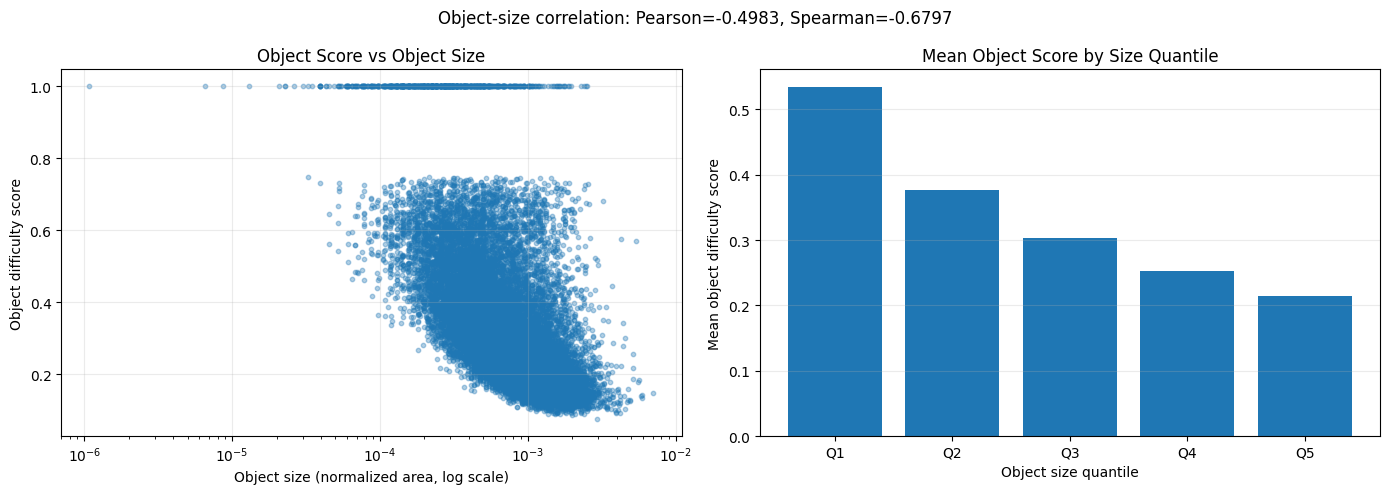

In [120]:
# Visualization: scatter plot and quantile analysis
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Scatter on log-size axis
ax[0].scatter(safe_sizes, obj_scores, s=10, alpha=0.35)
ax[0].set_xscale('log')
ax[0].set_xlabel('Object size (normalized area, log scale)')
ax[0].set_ylabel('Object difficulty score')
ax[0].set_title('Object Score vs Object Size')
ax[0].grid(alpha=0.25)

# Mean score by size quantile bins
q = np.quantile(safe_sizes, [0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
for i in range(1, len(q)):
    if q[i] <= q[i - 1]:
        q[i] = q[i - 1] + 1e-12
bins = np.digitize(safe_sizes, q[1:-1], right=True)
means = [float(np.mean(obj_scores[bins == i])) if np.any(bins == i) else np.nan for i in range(5)]
ax[1].bar(['Q1', 'Q2', 'Q3', 'Q4', 'Q5'], means)
ax[1].set_xlabel('Object size quantile')
ax[1].set_ylabel('Mean object difficulty score')
ax[1].set_title('Mean Object Score by Size Quantile')
ax[1].grid(axis='y', alpha=0.25)

fig.suptitle(f'Object-size correlation: Pearson={pearson_obj:.4f}, Spearman={spearman_obj:.4f}')
plt.tight_layout()
plt.show()

In [121]:
# Question 1 & 2: Analyze object size categories (small vs medium vs large)
# 
# Categories based on area (common in object detection):
# - Small:  area ≤ 32² = 1024 pixels
# - Medium: 32² < area < 96² = 9216 pixels  
# - Large:  area ≥ 96² = 9216 pixels
#
# Note: obj_sizes are in normalized coordinates [0,1], so we need to know image dimensions
# MinneApple images are 720x1280 pixels

image_width = 720
image_height = 1280
image_area = image_width * image_height  # pixels
small_threshold = (32**2) / image_area  # normalized
medium_threshold = (96**2) / image_area  # normalized

print('='*70)
print('SIZE CATEGORY THRESHOLDS')
print('='*70)
print(f'Image dimensions: {image_width}x{image_height} pixels (area={image_area})')
print(f'Small (area ≤ 1024 px²):        normalized ≤ {small_threshold:.6f}')
print(f'Medium (1024 < area < 9216 px²): normalized in ({small_threshold:.6f}, {medium_threshold:.6f})')
print(f'Large (area ≥ 9216 px²):         normalized ≥ {medium_threshold:.6f}')
print()

# Classify objects
is_small = obj_sizes <= small_threshold
is_medium = (obj_sizes > small_threshold) & (obj_sizes < medium_threshold)
is_large = obj_sizes >= medium_threshold

print(f'Distribution of objects by size category:')
print(f'  Small:  {np.sum(is_small):6d} ({np.sum(is_small)/len(obj_sizes)*100:6.2f}%)')
print(f'  Medium: {np.sum(is_medium):6d} ({np.sum(is_medium)/len(obj_sizes)*100:6.2f}%)')
print(f'  Large:  {np.sum(is_large):6d} ({np.sum(is_large)/len(obj_sizes)*100:6.2f}%)')
print()

SIZE CATEGORY THRESHOLDS
Image dimensions: 720x1280 pixels (area=921600)
Small (area ≤ 1024 px²):        normalized ≤ 0.001111
Medium (1024 < area < 9216 px²): normalized in (0.001111, 0.010000)
Large (area ≥ 9216 px²):         normalized ≥ 0.010000

Distribution of objects by size category:
  Small:   16793 ( 73.61%)
  Medium:   6022 ( 26.39%)
  Large:       0 (  0.00%)



In [ ]:
# ANSWER TO QUESTION 1:
# Of all objects with S_obj above 75th percentile, 
# what % are small, what % are medium?

p75 = np.percentile(obj_scores, 75)
above_p75 = obj_scores >= p75

print('='*70)
print('QUESTION 1: Among high-difficulty objects (S_obj ≥ 75th percentile)')
print('='*70)
print(f'75th percentile of S_obj: {p75:.4f}')
print(f'Number of objects ≥ 75th percentile: {np.sum(above_p75)}')
print()

# For objects above 75th percentile, compute percentages in each size category
high_diff_small = np.sum(is_small & above_p75)
high_diff_medium = np.sum(is_medium & above_p75)
high_diff_large = np.sum(is_large & above_p75)
total_high_diff = np.sum(above_p75)

if total_high_diff > 0:
    pct_small = (high_diff_small / total_high_diff) * 100
    pct_medium = (high_diff_medium / total_high_diff) * 100
    pct_large = (high_diff_large / total_high_diff) * 100
    
    print(f'Among high-difficulty objects:')
    print(f'  Small:  {high_diff_small:6d} objects ({pct_small:6.2f}%)')
    print(f'  Medium: {high_diff_medium:6d} objects ({pct_medium:6.2f}%)')
    print(f'  Large:  {high_diff_large:6d} objects ({pct_large:6.2f}%)')
    print()
else:
    print('No objects found above 75th percentile')
    pct_small = pct_medium = 0

QUESTION 1: Among high-difficulty objects (S_obj ≥ 75th percentile)
75th percentile of S_obj: 0.0741
Number of objects ≥ 75th percentile: 22815

Among high-difficulty objects:
  Small:   16793 objects ( 73.61%)
  Medium:   6022 objects ( 26.39%)
  Large:       0 objects (  0.00%)



In [123]:
# ANSWER TO QUESTION 2:
# What is the mean S_obj for small vs medium objects?

print('='*70)
print('QUESTION 2: Mean S_obj by size category')
print('='*70)

mean_score_small = np.mean(obj_scores[is_small]) if np.sum(is_small) > 0 else np.nan
mean_score_medium = np.mean(obj_scores[is_medium]) if np.sum(is_medium) > 0 else np.nan
mean_score_large = np.mean(obj_scores[is_large]) if np.sum(is_large) > 0 else np.nan

std_score_small = np.std(obj_scores[is_small]) if np.sum(is_small) > 0 else np.nan
std_score_medium = np.std(obj_scores[is_medium]) if np.sum(is_medium) > 0 else np.nan
std_score_large = np.std(obj_scores[is_large]) if np.sum(is_large) > 0 else np.nan

print(f'Small objects:')
print(f'  Count: {np.sum(is_small)}, Mean S_obj: {mean_score_small:.4f}, Std: {std_score_small:.4f}')
print()
print(f'Medium objects:')
print(f'  Count: {np.sum(is_medium)}, Mean S_obj: {mean_score_medium:.4f}, Std: {std_score_medium:.4f}')
print()
print(f'Large objects:')
print(f'  Count: {np.sum(is_large)}, Mean S_obj: {mean_score_large:.4f}, Std: {std_score_large:.4f}')
print()

QUESTION 2: Mean S_obj by size category
Small objects:
  Count: 16793, Mean S_obj: 0.3777, Std: 0.1956

Medium objects:
  Count: 6022, Mean S_obj: 0.2216, Std: 0.1220

Large objects:
  Count: 0, Mean S_obj: nan, Std: nan



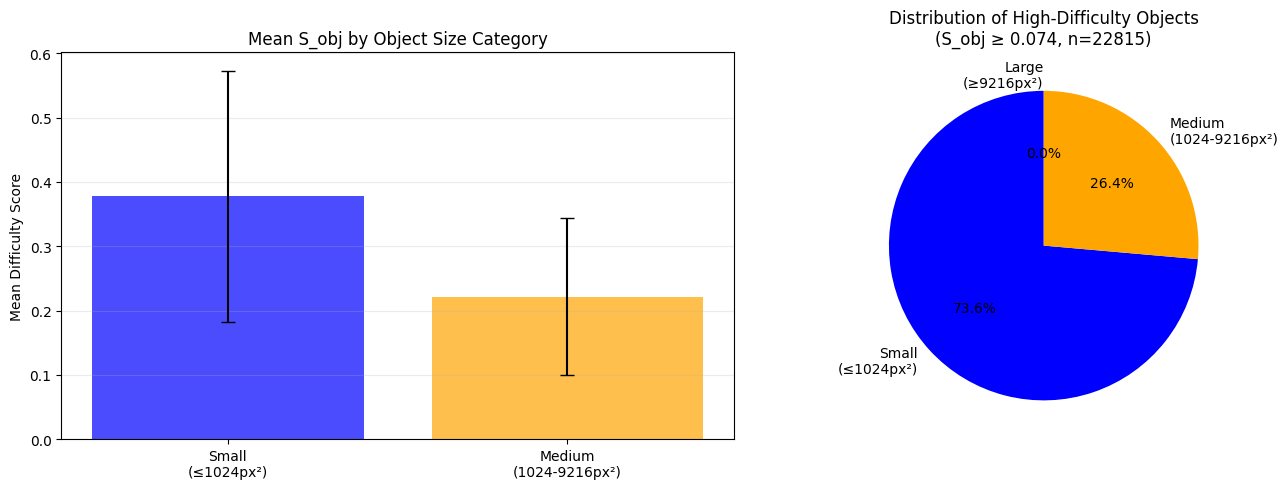

In [124]:
# Visualization: Compare mean scores across size categories
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of mean scores
categories = ['Small\n(≤1024px²)', 'Medium\n(1024-9216px²)', 'Large\n(≥9216px²)']
means = [mean_score_small, mean_score_medium, mean_score_large]
stds = [std_score_small, std_score_medium, std_score_large]

axes[0].bar(categories, means, yerr=stds, capsize=5, alpha=0.7, color=['blue', 'orange', 'green'])
axes[0].set_ylabel('Mean Difficulty Score')
axes[0].set_title('Mean S_obj by Object Size Category')
axes[0].grid(axis='y', alpha=0.25)

# Distribution of high-difficulty objects by size category
high_diff_pcts = [pct_small, pct_medium, pct_large]
colors = ['blue', 'orange', 'green']
axes[1].pie(high_diff_pcts, labels=categories, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title(f'Distribution of High-Difficulty Objects\n(S_obj ≥ {p75:.3f}, n={np.sum(above_p75)})')

plt.tight_layout()
plt.show()